#Praktikum4 Informed Search


Maze:

███████
█ █   █
█ █ █ █
█   █B█
█████ █
A     █
███████

Solving...
States Explored: 8
Solution:

███████
█ █   █
█ █ █ █
█   █B█
█████*█
A*****█
███████



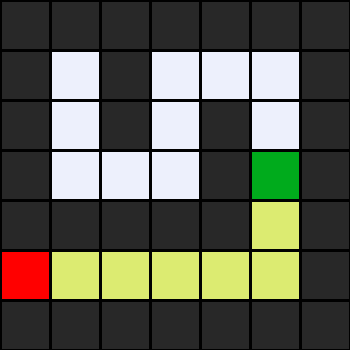

In [ ]:
import operator # library untuk me-sort kelasnya
from PIL import Image, ImageDraw
from IPython.display import display, Image as IPImage

maze_content = """\
#######
# #   #
# # # #
#   #B#
##### #
A     #
#######"""

class Node:
    def __init__(self, state, parent, action, heuristic):
        self.state = state
        self.parent = parent
        self.action = action
        # nilai heuristic
        self.heuristic = heuristic

class Greedy:
    def __init__(self):
        self.frontier = []

    def add(self, node):
        self.frontier.append(node)
        # fungsi mengurutkan node di frontier berdasarkan nilai heuristic
        self.frontier.sort(key=operator.attrgetter("heuristic"))

    def contains_state(self, state):
        return any(node.state == state for node in self.frontier)

    def empty(self):
        return len(self.frontier) == 0

    def remove(self):
        if self.empty():
            raise Exception("empty frontier")
        else:
            node = self.frontier[0]
            self.frontier = self.frontier[1:]
            return node

class Maze:
    def __init__(self, contents):
        # Read file and set height and width of maze
        contents = contents

        # Validate start and goal
        if contents.count("A") != 1:
            raise Exception("maze must have exactly one start point")
        if contents.count("B") != 1:
            raise Exception("maze must have exactly one goal")

        # Determine height and width of maze
        contents = contents.splitlines()
        self.height = len(contents)
        self.width = max(len(line) for line in contents)

        # Keep track of walls
        self.walls = []
        for i in range(self.height):
            row = []
            for j in range(self.width):
                try:
                    if contents[i][j] == "A":
                        self.start = (i, j)
                        row.append(False)
                    elif contents[i][j] == "B":
                        self.goal = (i, j)
                        row.append(False)
                    elif contents[i][j] == " ":
                        row.append(False)
                    else:
                        row.append(True)
                except IndexError:
                    row.append(False)
            self.walls.append(row)
        self.solution = None

    def print(self):
        solution = self.solution[1] if self.solution is not None else None
        print()
        for i, row in enumerate(self.walls):
            for j, col in enumerate(row):
                if col:
                    print("█", end="")
                elif (i, j) == self.start:
                    print("A", end="")
                elif (i, j) == self.goal:
                    print("B", end="")
                elif solution is not None and (i, j) in solution:
                    print("*", end="")
                else:
                    print(" ", end="")
            print()
        print()

    def neighbors(self, state):
        row, col = state
        candidates = [
            ("up", (row - 1, col)),
            ("down", (row + 1, col)),
            ("left", (row, col - 1)),
            ("right", (row, col + 1)),
        ]
        result = []
        for action, (r, c) in candidates:
            if 0 <= r < self.height and 0 <= c < self.width and not self.walls[r][c]:
                result.append((action, (r, c)))
        return result

    def solve(self):
        """Finds a solution to maze, if one exists."""
        # Keep track of number of states explored
        self.num_explored = 0

        # Initialize frontier to just the starting position
        start = Node(state=self.start, parent=None, action=None, heuristic=999)
        frontier = Greedy()
        frontier.add(start)

        # Initialize an empty explored set
        self.explored = set()

        # Keep looping until solution found
        while True:
            # If nothing left in frontier, then no path
            if frontier.empty():
                raise Exception("no solution")

            # Choose a node from the frontier
            node = frontier.remove()
            self.num_explored += 1

            # If node is the goal, then we have a solution
            if node.state == self.goal:
                actions = []
                cells = []
                while node.parent is not None:
                    actions.append(node.action)
                    cells.append(node.state)
                    node = node.parent
                actions.reverse()
                cells.reverse()
                self.solution = (actions, cells)
                return

            # Mark node as explored
            self.explored.add(node.state)

            # Add neighbors to frontier
            for action, state in self.neighbors(node.state):
                if not frontier.contains_state(state) and state not in self.explored:
                    heuristic = 0
                    if self.goal[0] > state[0]:
                        heuristic = self.goal[0] - state[0]
                    else:
                        heuristic = state[0] - self.goal[0]
                    if self.goal[1] > state[1]:
                        heuristic += self.goal[1] - state[1]
                    else:
                        heuristic += state[1] - self.goal[1]
                    child = Node(
                        state=state, parent=node, action=action, heuristic=heuristic
                    )
                    frontier.add(child)

    def output_image(self, filename, show_solution=True, show_explored=False):
        cell_size = 50
        cell_border = 2

        # Create a blank canvas
        img = Image.new(
            "RGBA", (self.width * cell_size, self.height * cell_size), "black"
        )
        draw = ImageDraw.Draw(img)
        solution = self.solution[1] if self.solution is not None else None
        for i, row in enumerate(self.walls):
            for j, col in enumerate(row):
                if col:
                    fill = (40, 40, 40)
                elif (i, j) == self.start:
                    fill = (255, 0, 0)
                elif (i, j) == self.goal:
                    fill = (0, 171, 28)
                elif solution is not None and show_solution and (i, j) in solution:
                    fill = (220, 235, 113)
                elif solution is not None and show_explored and (i, j) in self.explored:
                    fill = (212, 97, 85)
                else:
                    fill = (237, 240, 252)
                draw.rectangle(
                    (
                        [
                            (j * cell_size + cell_border, i * cell_size + cell_border),
                            (
                                (j + 1) * cell_size - cell_border,
                                (i + 1) * cell_size - cell_border,
                            ),
                        ]
                    ),
                    fill=fill,
                )
        img.save(filename)

m = Maze(maze_content)
print("Maze:")
m.print()
print("Solving...")
m.solve()
print("States Explored:", m.num_explored)
print("Solution:")
m.print()
m.output_image("maze.png", show_explored=True)
display(IPImage("maze.png"))

In [ ]:
#3 Greedy Best First Algorithm
import heapq

# Data dari file jalan.txt dimasukkan langsung
jalan_data = """Arad,Zerind,75
Arad,Sibiu,140
Arad,Timisoara,118
Zerind,Oradea,71
Oradea,Sibiu,151
Timisoara,Lugoj,111
Sibiu,Fagaras,99
Sibiu,Rimnicu Vilcea,80
Lugoj,Mehadia,70
Fagaras,Bucharest,211
Rimnicu Vilcea,Pitesti,97
Rimnicu Vilcea,Craiova,146
Mehadia,Dobreta,75
Bucharest,Pitesti,101
Bucharest,Urziceni,85
Bucharest,Giurgiu,90
Pitesti,Craiova,138
Craiova,Dobreta,120
Urziceni,Hirsova,98
Urziceni,Vaslui,142
Hirsova,Eforie,86
Vaslui,Lasi,92
Lasi,Neamt,87"""

# Data dari file heuristicjalan.txt dimasukkan langsung
heuristic_data = """Arad,366
Bucharest,0
Craiova,160
Dobreta,242
Eforie,161
Fagaras,176
Giurgiu,77
Hirsova,151
Lasi,226
Lugoj,244
Mehadia,241
Neamt,234
Oradea,380
Pitesti,100
Rimnicu Vilcea,193
Sibiu,253
Timisoara,329
Urziceni,80
Vaslui,199
Zerind,374"""

jalur = {}  # Inisialisasi dictionary kosong untuk merepresentasikan graf jaringan jalan di Romania.

# Definisi kelas PriorityQueue untuk implementasi antrian prioritas.
class PriorityQueue:
    def __init__(self) -> None:
        self.cities = []  # Inisialisasi daftar kosong untuk menyimpan elemen antrian prioritas.

    def isEmpty(self):
        if self.cities == []:
            return True
        return False

    def check(self):
        print(self.cities)

    def push(self, city, cost):
        heapq.heappush(self.cities, (cost, city))  # Menambahkan elemen ke antrian prioritas berdasarkan biaya.

    def pop(self):
        return heapq.heappop(self.cities)[1]  # Menghapus dan mengembalikan elemen dengan biaya terendah.

# Definisi kelas CityNode untuk merepresentasikan node kota dalam graf.
class CityNode:
    def __init__(self, city, distance) -> None:
        self.city = str(city)
        self.distance = str(distance)

# Fungsi untuk membaca data jalan dan membangun graf di dalam dictionary "jalur".
def makeDict():
    for str_line in jalan_data.strip().split('\n'):
        delimeter = str_line.split(',')
        city1 = delimeter[0]
        city2 = delimeter[1]
        dist = delimeter[2]
        jalur.setdefault(city1, []).append(CityNode(city2, dist))
        jalur.setdefault(city2, []).append(CityNode(city1, dist))

# Fungsi untuk membaca data heuristik dan membangun dictionary nilai heuristik "h".
def makeHeuristicDict():
    h = {}
    for str_line in heuristic_data.strip().split('\n'):
        delimeter = str_line.strip().split(',')
        node = delimeter[0].strip()
        sld = int(delimeter[1].strip())  # Jalan lurus
        h[node] = sld
    return h

# Fungsi heuristik yang digunakan dalam pencarian GBFS.
def heuristic(node, values):
    return values[node]

# Fungsi utama yang menjalankan algoritma GBFS.
def greedyBFS(start, end):
    path = {}
    q = PriorityQueue()
    h = makeHeuristicDict()

    q.push(start, 0)
    path[start] = None
    expandList = []

    while q.isEmpty() == False:
        curr = q.pop()
        expandList.append(curr)

        if curr == end:
            break

        for new in jalur[curr]:
            if new.city not in path:
                f_cost = heuristic(new.city, h)
                q.push(new.city, f_cost)
                path[new.city] = curr

    # Fungsi untuk mencetak output hasil pencarian.
    printOutput(start, end, path, expandList)

# Fungsi untuk mencetak output hasil pencarian.
def printOutput(start, end, path, expandList):
    finalpath = []
    i = end

    while (path.get(i) != None):
        finalpath.append(i)
        i = path[i]
    finalpath.append(start)
    finalpath.reverse()

    print("Program Greedy Best-First-Search")
    print(start + " => " + end)
    print("Kota yg dilewati dg jarak terpendek\t: " + str(finalpath))

# Fungsi utama yang dijalankan saat skrip ini dieksekusi.
def main():
    src = "Arad"
    dst = "Bucharest"
    makeDict()
    greedyBFS(src, dst)

# Pengecekan apakah skrip ini dijalankan sebagai program utama.
if __name__ == "__main__":
    main()

Program Greedy Best-First-Search
Arad => Bucharest
Kota yg dilewati dg jarak terpendek	: ['Arad', 'Sibiu', 'Fagaras', 'Bucharest']


In [ ]:
#4 A * Star Algorithm
def aStarAlgo(start_node, stop_node):
    open_set = set(start_node)
    closed_set = set()
    g = {}  # store distance from starting node
    parents = {}  # parents contains an adjacency map of all nodes

    # ditance of starting node from itself is zero
    g[start_node] = 0

    # start_node is root node i.e it has no parent nodes
    # so start_node is set to its own parent node
    parents[start_node] = start_node

    while len(open_set) > 0:
        n = None

        # node with lowest f() is found
        for v in open_set:
            if n == None or g[v] + heuristic(v) < g[n] + heuristic(n):
                n = v

        if n == stop_node or Graph_nodes[n] == None:
            pass
        else:
            for (m, weight) in get_neighbors(n):
                # nodes 'm' not in first and last set are added to first
                # n is set its parent
                if m not in open_set and m not in closed_set:
                    open_set.add(m)
                    parents[m] = n
                    g[m] = g[n] + weight

                # for each node m,compare its distance from start i.e g(m) to the
                # from start through n node
                else:
                    if g[m] > g[n] + weight:
                        # update g(m)
                        g[m] = g[n] + weight
                        # change parent of m to n
                        parents[m] = n

                        # if m in closed set,remove and add to open
                        if m in closed_set:
                            closed_set.remove(m)
                            open_set.add(m)

        if n == None:
            print('Path does not exist!')
            return None

        # if the current node is the stop_node
        # then we begin reconstructin the path from it to the start_node
        if n == stop_node:
            path = []

            while parents[n] != n:
                path.append(n)
                n = parents[n]
            path.append(start_node)
            path.reverse()

            print('Path found: {}'.format(path))
            return path

        # remove n from the open_list, and add it to closed_list
        # because all of his neighbors were inspected
        open_set.remove(n)
        closed_set.add(n)

    print('Path does not exist!')
    return None

# define fuction to return neighbor and its distance
# from the passed node
def get_neighbors(v):
    if v in Graph_nodes:
        return Graph_nodes[v]
    else:
        return None

# for simplicity we ll consider heuristic distances given
# and this function returns heuristic distance for all nodes
def heuristic(n):
    H_dist = {
        'A': 11,
        'B': 6,
        'C': 99,
        'D': 1,
        'E': 7,
        'G': 0,
    }
    return H_dist[n]

# Describe your graph here
Graph_nodes = {
    'A': [('B', 2), ('E', 3)],
    'B': [('C', 1), ('G', 9)],
    'C': None,
    'E': [('D', 6)],
    'D': [('G', 1)],
}

aStarAlgo('A', 'G')

Path found: ['A', 'E', 'D', 'G']


['A', 'E', 'D', 'G']

Maze:

█████████
█       █
█ ██ ██ █
█ █Z █  █
█ ██ ██ █
█    █  █
██ ███ ██
█       █
█ █████ █
█     █ █
█████ █ █
A       █
█████████

Solving...
States Explored: 22
Solution:

█████████
█       █
█ ██ ██ █
█ █Z*█  █
█ ██*██ █
█ ***█  █
██*███ ██
█**     █
█*█████ █
█*****█ █
█████*█ █
A*****  █
█████████



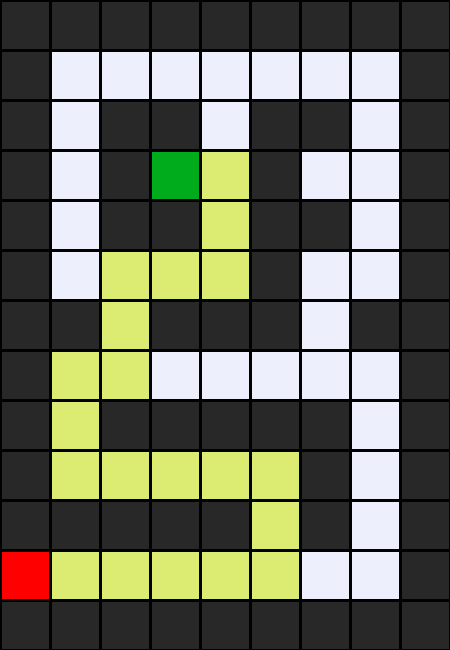

In [ ]:
#5. Study Kasus
import operator # library untuk me-sort kelasnya
from PIL import Image, ImageDraw
from IPython.display import display, Image as IPImage

# Maze dari A menuju Z sesuai soal no.5
maze_content = """\
#########
#       #
# ## ## #
# #Z #  #
# ## ## #
#    #  #
## ### ##
#       #
# ##### #
#     # #
##### # #
A       #
#########"""

class Node:
    def __init__(self, state, parent, action, heuristic):
        self.state = state
        self.parent = parent
        self.action = action
        # nilai heuristic
        self.heuristic = heuristic

class Greedy:
    def __init__(self):
        self.frontier = []

    def add(self, node):
        self.frontier.append(node)
        # fungsi mengurutkan node di frontier berdasarkan nilai heuristic
        self.frontier.sort(key=operator.attrgetter("heuristic"))

    def contains_state(self, state):
        return any(node.state == state for node in self.frontier)

    def empty(self):
        return len(self.frontier) == 0

    def remove(self):
        if self.empty():
            raise Exception("empty frontier")
        else:
            node = self.frontier[0]
            self.frontier = self.frontier[1:]
            return node

class Maze:
    def __init__(self, contents):
        # Read file and set height and width of maze
        contents = contents

        # Validate start and goal
        if contents.count("A") != 1:
            raise Exception("maze must have exactly one start point")
        if contents.count("Z") != 1: # Changed from 'B' to 'Z'
            raise Exception("maze must have exactly one goal")

        # Determine height and width of maze
        contents = contents.splitlines()
        self.height = len(contents)
        self.width = max(len(line) for line in contents)

        # Keep track of walls
        self.walls = []
        for i in range(self.height):
            row = []
            for j in range(self.width):
                try:
                    if contents[i][j] == "A":
                        self.start = (i, j)
                        row.append(False)
                    elif contents[i][j] == "Z": # Changed from 'B' to 'Z'
                        self.goal = (i, j)
                        row.append(False)
                    elif contents[i][j] == " ":
                        row.append(False)
                    else:
                        row.append(True)
                except IndexError:
                    row.append(False)
            self.walls.append(row)
        self.solution = None

    def print(self):
        solution = self.solution[1] if self.solution is not None else None
        print()
        for i, row in enumerate(self.walls):
            for j, col in enumerate(row):
                if col:
                    print("█", end="")
                elif (i, j) == self.start:
                    print("A", end="")
                elif (i, j) == self.goal:
                    print("Z", end="")
                elif solution is not None and (i, j) in solution:
                    print("*", end="")
                else:
                    print(" ", end="")
            print()
        print()

    def neighbors(self, state):
        row, col = state
        candidates = [
            ("up", (row - 1, col)),
            ("down", (row + 1, col)),
            ("left", (row, col - 1)),
            ("right", (row, col + 1)),
        ]
        result = []
        for action, (r, c) in candidates:
            if 0 <= r < self.height and 0 <= c < self.width and not self.walls[r][c]:
                result.append((action, (r, c)))
        return result

    def solve(self):
        """Finds a solution to maze, if one exists."""
        # Keep track of number of states explored
        self.num_explored = 0

        # Initialize frontier to just the starting position
        start = Node(state=self.start, parent=None, action=None, heuristic=999)
        frontier = Greedy()
        frontier.add(start)

        # Initialize an empty explored set
        self.explored = set()

        # Keep looping until solution found
        while True:
            # If nothing left in frontier, then no path
            if frontier.empty():
                raise Exception("no solution")

            # Choose a node from the frontier
            node = frontier.remove()
            self.num_explored += 1

            # If node is the goal, then we have a solution
            if node.state == self.goal:
                actions = []
                cells = []
                while node.parent is not None:
                    actions.append(node.action)
                    cells.append(node.state)
                    node = node.parent
                actions.reverse()
                cells.reverse()
                self.solution = (actions, cells)
                return

            # Mark node as explored
            self.explored.add(node.state)

            # Add neighbors to frontier
            for action, state in self.neighbors(node.state):
                if not frontier.contains_state(state) and state not in self.explored:
                    heuristic = 0
                    if self.goal[0] > state[0]:
                        heuristic = self.goal[0] - state[0]
                    else:
                        heuristic = state[0] - self.goal[0]
                    if self.goal[1] > state[1]:
                        heuristic += self.goal[1] - state[1]
                    else:
                        heuristic += state[1] - self.goal[1]
                    child = Node(
                        state=state, parent=node, action=action, heuristic=heuristic
                    )
                    frontier.add(child)

    def output_image(self, filename, show_solution=True, show_explored=False):
        cell_size = 50
        cell_border = 2

        # Create a blank canvas
        img = Image.new(
            "RGBA", (self.width * cell_size, self.height * cell_size), "black"
        )
        draw = ImageDraw.Draw(img)
        solution = self.solution[1] if self.solution is not None else None
        for i, row in enumerate(self.walls):
            for j, col in enumerate(row):
                if col:
                    fill = (40, 40, 40)
                elif (i, j) == self.start:
                    fill = (255, 0, 0)
                elif (i, j) == self.goal:
                    fill = (0, 171, 28)
                elif solution is not None and show_solution and (i, j) in solution:
                    fill = (220, 235, 113)
                elif solution is not None and show_explored and (i, j) in self.explored:
                    fill = (212, 97, 85)
                else:
                    fill = (237, 240, 252)
                draw.rectangle(
                    (
                        [
                            (j * cell_size + cell_border, i * cell_size + cell_border),
                            (
                                (j + 1) * cell_size - cell_border,
                                (i + 1) * cell_size - cell_border,
                            ),
                        ]
                    ),
                    fill=fill,
                )
        img.save(filename)

m = Maze(maze_content)
print("Maze:")
m.print()
print("Solving...")
m.solve()
print("States Explored:", m.num_explored)
print("Solution:")
m.print()
m.output_image("maze.png", show_explored=True)
display(IPImage("maze.png"))

In [ ]:
#6. Study Kasus
def aStarAlgo(start_node, stop_node):
    open_set = set(start_node)
    closed_set = set()
    g = {}  # store distance from starting node
    parents = {}  # parents contains an adjacency map of all nodes

    # ditance of starting node from itself is zero
    g[start_node] = 0

    # start_node is root node i.e it has no parent nodes
    # so start_node is set to its own parent node
    parents[start_node] = start_node

    while len(open_set) > 0:
        n = None

        # node with lowest f() is found
        for v in open_set:
            if n == None or g[v] + heuristic(v) < g[n] + heuristic(n):
                n = v

        if n == stop_node or Graph_nodes[n] == None:
            pass
        else:
            for (m, weight) in get_neighbors(n):
                # nodes 'm' not in first and last set are added to first
                # n is set its parent
                if m not in open_set and m not in closed_set:
                    open_set.add(m)
                    parents[m] = n
                    g[m] = g[n] + weight

                # for each node m,compare its distance from start i.e g(m) to the
                # from start through n node
                else:
                    if g[m] > g[n] + weight:
                        # update g(m)
                        g[m] = g[n] + weight
                        # change parent of m to n
                        parents[m] = n

                        # if m in closed set,remove and add to open
                        if m in closed_set:
                            closed_set.remove(m)
                            open_set.add(m)

        if n == None:
            print('Path does not exist!')
            return None

        # if the current node is the stop_node
        # then we begin reconstructin the path from it to the start_node
        if n == stop_node:
            path = []

            while parents[n] != n:
                path.append(n)
                n = parents[n]
            path.append(start_node)
            path.reverse()

            print('Path found: {}'.format(path))
            return path

        # remove n from the open_list, and add it to closed_list
        # because all of his neighbors were inspected
        open_set.remove(n)
        closed_set.add(n)

    print('Path does not exist!')
    return None

# define fuction to return neighbor and its distance
# from the passed node
def get_neighbors(v):
    if v in Graph_nodes:
        return Graph_nodes[v]
    else:
        return None

# for simplicity we ll consider heuristic distances given
# and this function returns heuristic distance for all nodes
def heuristic(n):
    H_dist = {
        'S': 7,
        'A': 9,
        'B': 4,
        'C': 2,
        'D': 5,
        'E': 3,
        'G': 0,
    }
    return H_dist[n]

# Describe your graph here
# Sesuai gambar soal no.6
Graph_nodes = {
    'S': [('A', 3), ('D', 2)],
    'A': [('B', 5), ('S', 3)],
    'B': [('A', 5), ('C', 2), ('D', 1), ('E', 1)],
    'C': [('B', 2), ('G', 4)],
    'D': [('S', 2), ('B', 1), ('E', 4)],
    'E': [('B', 1), ('D', 4), ('G', 3)],
    'G': [('C', 4), ('E', 3)],
}

aStarAlgo('S', 'G')

Path found: ['S', 'D', 'B', 'E', 'G']


['S', 'D', 'B', 'E', 'G']

In [ ]:
#7. Study Kasus
import heapq

# Data dari file jalan.txt
jalan_data = """Arad,Zerind,75
Arad,Sibiu,140
Arad,Timisoara,118
Zerind,Oradea,71
Oradea,Sibiu,151
Timisoara,Lugoj,111
Sibiu,Fagaras,99
Sibiu,Rimnicu Vilcea,80
Lugoj,Mehadia,70
Fagaras,Bucharest,211
Rimnicu Vilcea,Pitesti,97
Rimnicu Vilcea,Craiova,146
Mehadia,Dobreta,75
Bucharest,Pitesti,101
Bucharest,Urziceni,85
Bucharest,Giurgiu,90
Pitesti,Craiova,138
Craiova,Dobreta,120
Urziceni,Hirsova,98
Urziceni,Vaslui,142
Hirsova,Eforie,86
Vaslui,Lasi,92
Lasi,Neamt,87"""

# Data dari file heuristicjalan.txt
heuristic_data = """Arad,366
Bucharest,0
Craiova,160
Dobreta,242
Eforie,161
Fagaras,176
Giurgiu,77
Hirsova,151
Lasi,226
Lugoj,244
Mehadia,241
Neamt,234
Oradea,380
Pitesti,100
Rimnicu Vilcea,193
Sibiu,253
Timisoara,329
Urziceni,80
Vaslui,199
Zerind,374"""

# Bangun graf
graph = {}
graph_weighted = {}

for line in jalan_data.strip().split('\n'):
    parts = line.split(',')
    city1, city2, dist = parts[0], parts[1], int(parts[2])
    graph.setdefault(city1, []).append(city2)
    graph.setdefault(city2, []).append(city1)
    graph_weighted.setdefault(city1, {}).update({city2: dist})
    graph_weighted.setdefault(city2, {}).update({city1: dist})

# Bangun heuristik
heuristic_dict = {}
for line in heuristic_data.strip().split('\n'):
    parts = line.strip().split(',')
    heuristic_dict[parts[0].strip()] = int(parts[1].strip())

# =====================
# 1. BFS
# =====================
def bfs(start, end):
    queue = [[start]]
    visited = set()

    while queue:
        path = queue.pop(0)
        node = path[-1]

        if node == end:
            return path

        if node not in visited:
            visited.add(node)
            for neighbor in graph.get(node, []):
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)

    return None

# =====================
# 2. DFS
# =====================
def dfs(start, end):
    stack = [[start]]
    visited = set()

    while stack:
        path = stack.pop()
        node = path[-1]

        if node == end:
            return path

        if node not in visited:
            visited.add(node)
            for neighbor in reversed(graph.get(node, [])):
                new_path = list(path)
                new_path.append(neighbor)
                stack.append(new_path)

    return None

# =====================
# 3. UCS
# =====================
def ucs(start, end):
    queue = []
    heapq.heappush(queue, (0, start))
    path_cost = {start: 0}
    path = {}

    while queue:
        cost, node = heapq.heappop(queue)

        if node == end:
            path_nodes = []
            while node != start:
                path_nodes.append(node)
                node = path[node]
            path_nodes.append(start)
            return list(reversed(path_nodes)), cost

        for neighbor, weight in graph_weighted.get(node, {}).items():
            new_cost = cost + weight
            if neighbor not in path_cost or new_cost < path_cost[neighbor]:
                path_cost[neighbor] = new_cost
                heapq.heappush(queue, (new_cost, neighbor))
                path[neighbor] = node

    return None

# =====================
# 4. GBFS
# =====================
def gbfs(start, end):
    queue = []
    heapq.heappush(queue, (heuristic_dict.get(start, 0), start))
    path = {start: None}
    visited = set()

    while queue:
        _, node = heapq.heappop(queue)

        if node == end:
            path_nodes = []
            while node is not None:
                path_nodes.append(node)
                node = path[node]
            return list(reversed(path_nodes))

        if node not in visited:
            visited.add(node)
            for neighbor in graph.get(node, []):
                if neighbor not in visited:
                    heapq.heappush(queue, (heuristic_dict.get(neighbor, 0), neighbor))
                    if neighbor not in path:
                        path[neighbor] = node

    return None

# =====================
# 5. A*
# =====================
def astar(start, end):
    queue = []
    heapq.heappush(queue, (0, start))
    g = {start: 0}
    path = {start: None}

    while queue:
        _, node = heapq.heappop(queue)

        if node == end:
            path_nodes = []
            while node is not None:
                path_nodes.append(node)
                node = path[node]
            return list(reversed(path_nodes)), g[end]

        for neighbor, weight in graph_weighted.get(node, {}).items():
            new_g = g[node] + weight
            if neighbor not in g or new_g < g[neighbor]:
                g[neighbor] = new_g
                f = new_g + heuristic_dict.get(neighbor, 0)
                heapq.heappush(queue, (f, neighbor))
                path[neighbor] = node

    return None

# =====================
# MAIN PROGRAM
# =====================
def main():
    print("=" * 50)
    print("   Program Pencarian Rute Kota di Romania")
    print("=" * 50)

    # Tampilkan daftar kota
    print("\nDaftar Kota yang Tersedia:")
    cities = sorted(graph.keys())
    for i, city in enumerate(cities, 1):
        print(f"  {i}. {city}")

    print()
    src = input("Masukkan kota asal    : ")
    dst = input("Masukkan kota tujuan  : ")

    if src not in graph or dst not in graph:
        print("Kota tidak ditemukan!")
        return

    print("\nPilih Algoritma:")
    print("  1. BFS  (Breadth-First Search)")
    print("  2. DFS  (Depth-First Search)")
    print("  3. UCS  (Uniform-Cost Search)")
    print("  4. GBFS (Greedy Best-First Search)")
    print("  5. A*   (A-Star Search)")

    pilihan = input("\nMasukkan pilihan (1-5): ")

    print()
    print("=" * 50)

    if pilihan == '1':
        result = bfs(src, dst)
        print("Algoritma    : BFS")
        print(f"Rute         : {src} => {dst}")
        print(f"Jalur        : {result}")

    elif pilihan == '2':
        result = dfs(src, dst)
        print("Algoritma    : DFS")
        print(f"Rute         : {src} => {dst}")
        print(f"Jalur        : {result}")

    elif pilihan == '3':
        result = ucs(src, dst)
        print("Algoritma    : UCS")
        print(f"Rute         : {src} => {dst}")
        if result:
            print(f"Jalur        : {result[0]}")
            print(f"Total Jarak  : {result[1]} km")

    elif pilihan == '4':
        result = gbfs(src, dst)
        print("Algoritma    : GBFS")
        print(f"Rute         : {src} => {dst}")
        print(f"Jalur        : {result}")

    elif pilihan == '5':
        result = astar(src, dst)
        print("Algoritma    : A*")
        print(f"Rute         : {src} => {dst}")
        if result:
            print(f"Jalur        : {result[0]}")
            print(f"Total Jarak  : {result[1]} km")

    else:
        print("Pilihan tidak valid!")

    print("=" * 50)

main()

   Program Pencarian Rute Kota di Romania

Daftar Kota yang Tersedia:
  1. Arad
  2. Bucharest
  3. Craiova
  4. Dobreta
  5. Eforie
  6. Fagaras
  7. Giurgiu
  8. Hirsova
  9. Lasi
  10. Lugoj
  11. Mehadia
  12. Neamt
  13. Oradea
  14. Pitesti
  15. Rimnicu Vilcea
  16. Sibiu
  17. Timisoara
  18. Urziceni
  19. Vaslui
  20. Zerind

Masukkan kota asal    : Arad
Masukkan kota tujuan  : Bucharest

Pilih Algoritma:
  1. BFS  (Breadth-First Search)
  2. DFS  (Depth-First Search)
  3. UCS  (Uniform-Cost Search)
  4. GBFS (Greedy Best-First Search)
  5. A*   (A-Star Search)

Masukkan pilihan (1-5): 5

Algoritma    : A*
Rute         : Arad => Bucharest
Jalur        : ['Arad', 'Sibiu', 'Rimnicu Vilcea', 'Pitesti', 'Bucharest']
Total Jarak  : 418 km
